In [1]:
import numpy as np
import pandas as pd
from math import e
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
data = {
    'temperature': [10, 15, 20, 25, 30, 35],
    'humidity':    [30, 40, 50, 60, 70, 80],
    'y':           [ 0,  0,  1,  1,  1,  0]
}
df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,1
5,35,80,0


In [3]:
mask0 = df['y'] == 0
mask1 = df['y'] == 1

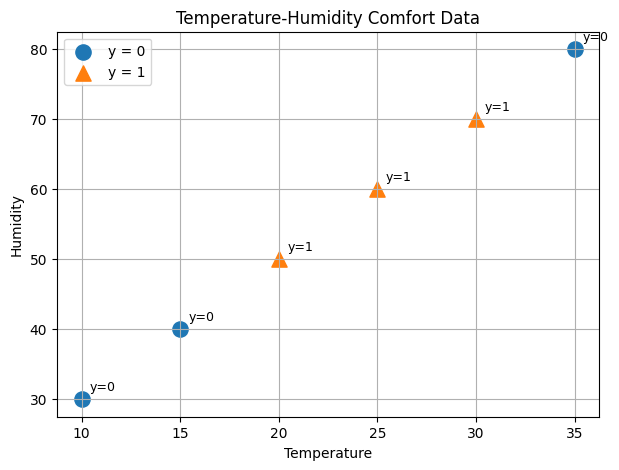

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df.loc[mask0, 'temperature'], df.loc[mask0, 'humidity'], marker='o', s=120, label='y = 0')
plt.scatter(df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'], marker='^', s=120, label='y = 1')

for temp, hum, yv in zip(df['temperature'], df['humidity'], df['y']):
    plt.annotate(f'y={yv}', (temp, hum), textcoords='offset points', xytext=(6, 6), fontsize=9)

plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Temperature-Humidity Comfort Data')
plt.legend()
plt.grid(True)

In [5]:
#  입력값 numpy배열로 만들기 (n, 2)
X_raw = df[['temperature', 'humidity']].to_numpy(dtype=float)
# 정답도 계산에 맞도록 (n, 1) 세로벡터로 만들기
y = df['y'].to_numpy(dtype=float).reshape(-1, 1)
X_raw, y

(array([[10., 30.],
        [15., 40.],
        [20., 50.],
        [25., 60.],
        [30., 70.],
        [35., 80.]]),
 array([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.]]))

In [6]:
# axis=0: 열방향 계산. 컬럼별 평균
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)
X_mean, X_std

(array([[22.5, 55. ]]), array([[ 8.53912564, 17.07825128]]))

In [7]:
# 서로다른 단위. -> 정규화 필요
X_norm = (X_raw - X_mean) / X_std
X_raw.shape, y.shape, X_norm.shape

((6, 2), (6, 1), (6, 2))

In [8]:
df['temperature_norm'] = X_norm[:, 0]
df['humidity_norm'] = X_norm[:, 1]
df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,1,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [9]:
def sigmoid(H):
    # 너무크거나 작은값 자르기
    H_clip = np.clip(H, -500, 500)
    z = 1.0 / (1.0 + e **(-H_clip))
    return z

In [10]:
def bce_cost(y, z):
    epsilon = 1e-7
    # z범위 제한해서 log계산 안정적으로 만들기
    z_clip = np.clip(z, epsilon, 1.0 - epsilon)
    # bce 계산
    cost = -(y * np.log(z_clip) + (1.0 - y) * np.log(1.0 - z_clip))
    return np.mean(cost)

In [11]:
X1_norm = X_norm[:, [0]]
X2_norm = X_norm[:, [1]]

In [12]:
# np.random.randn()은 평균 0, 표준편차 1 의 정규분포난수를 만듬.
# 난수에 0.1을 곱하는 이유는 처음부터 가중치가 너무 크면 sigmoid출력이 0 또는 1에 너무 가까이 붙어버려 
# 학습이 잘 진행되지 않을 수 있기 때문.

# 히든뉴런 1 가중치
a11 = np.random.randn() * 0.1 # 온도
a12 = np.random.randn() * 0.1 # 습도
b1 = 0.0
# 히든뉴런 2 가중치
a21 = np.random.randn() * 0.1
a22 = np.random.randn() * 0.1
b2 = 0.0
# 출력층
a31 = np.random.randn() * 0.1
a32 = np.random.randn() * 0.1
b3 = 0.0

In [13]:
# 초기 파라미터
param_table = pd.DataFrame({
    'name':    ['a11', 'a12', 'b1', 'a21', 'a22', 'b2', 'a31', 'a32', 'b3'],
    'value':   [round(v, 4) for v in [a11, a12, b1, a21, a22, b2, a31, a32, b3]],
    'meaning': [
        'X1(온도) -> 히든 뉴런 1 가중치',
        'X2(습도) -> 히든 뉴런 1 가중치',
        '히든 뉴런 1 편향',
        'X2(온도) -> 히든 뉴런 2 가중치',
        'X2(습도) -> 히든 뉴런 2 가중치',
        '히든 뉴런 1 편향',
        'z_hidden_1 -> 출력층 가중치',
        'z_hidden_2 -> 출력층 가중치',
        '출력층 편향'
    ]
})
param_table

,name,value,meaning
0,a11,0.0497,X1(온도) -> 히든 뉴런 1 가중치
1,a12,-0.0138,X2(습도) -> 히든 뉴런 1 가중치
2,b1,0.0000,히든 뉴런 1 편향
3,a21,0.0648,X2(온도) -> 히든 뉴런 2 가중치
4,a22,0.1523,X2(습도) -> 히든 뉴런 2 가중치
5,b2,0.0000,히든 뉴런 1 편향
6,a31,-0.0234,z_hidden_1 -> 출력층 가중치
7,a32,-0.0234,z_hidden_2 -> 출력층 가중치
8,b3,0.0000,출력층 편향


In [14]:
def mlp_forward_textbook_style(
        X1, X2, a11, a12, b1, a21, a22, b2, a31, a32, b3
):
    # 현재 파라미터로 예측확률 계산하는 순전파 함수
    # X1, X2는 원본이 아니라 (n,1) 세로벡터로 만든 정규화된 온도, 습도
    # 반환값 요약:
    # H_hidden_1, H_hidden_2, H_output -> sigmoid 이전의 선형 계산값
    # z_hidden_1, z_hidden_2: 중간 출력값
    # z_output -> 최종 예측 확률

    # --- 히든 뉴런 1 ---
    H_hidden_1 = a11 * X1 + a12 * X2 + b1
    z_hidden_1 = sigmoid(H_hidden_1)

    # --- 히든 뉴런 2 ---
    H_hidden_2 = a21 * X1 + a22 * X2 + b2
    z_hidden_2 = sigmoid(H_hidden_2)

    # --- 출력층 ---
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = sigmoid(H_output)

    return H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output


In [15]:
H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output = mlp_forward_textbook_style(
    X1_norm, X2_norm, a11, a12, b1, a21, a22, b2, a31, a32, b3
)

forward_shape_table = pd.DataFrame({
    'name':     ['H_hidden_1', 'z_hidden_1', 'H_hidden_2', 'z_hidden_2', 'H_output', 'z_output'],
    'shape':    [str(H_hidden_1.shape), str(z_hidden_1.shape), str(H_hidden_2.shape),
                 str(z_hidden_2.shape), str(H_output.shape), str(z_output.shape)],
    'meaning':  [
        '히든 뉴런 1 선형 출력',
        '히든 뉴런 1 시그모이드',
        '히든 뉴런 2 선형 출력',
        '히든 뉴런 2 시그모이드',
        '출력층 선형 출력',
        '최종 예측 확률'
    ]
})

forward_shape_table

,name,shape,meaning
0,H_hidden_1,"(6, 1)",히든 뉴런 1 선형 출력
1,z_hidden_1,"(6, 1)",히든 뉴런 1 시그모이드
2,H_hidden_2,"(6, 1)",히든 뉴런 2 선형 출력
3,z_hidden_2,"(6, 1)",히든 뉴런 2 시그모이드
4,H_output,"(6, 1)",출력층 선형 출력
5,z_output,"(6, 1)",최종 예측 확률


In [16]:
# MLP학습 설정
learning_rate = 0.5
epochs = 30000

# 학습 도중 관찰할 대표 데이터 1개 지정
trace_row_idx = 0
# 학습 데이터 개수
n = X1_norm.shape[0]

In [17]:
cost_history = []

for epoch in range(epochs):
    # 히든레이어
    # 히든뉴런 1
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
    z_hidden_1 = sigmoid(H_hidden_1)
    # 히든뉴런 2
    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
    z_hidden_2 = sigmoid(H_hidden_2)
    # 출력층
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = sigmoid(H_output)
    cost = bce_cost(y, z_output)
    cost_history.append(cost)

    # gradient 계산
    dH_output = z_output - y
    grad_a31 = np.mean(dH_output * z_hidden_1)
    grad_a32 = np.mean(dH_output * z_hidden_2)
    grad_b3 = np.mean(dH_output)

    dH_hidden_1 = (dH_output * a31) * z_hidden_1 * (1 - z_hidden_1)
    grad_a11 = np.mean(dH_hidden_1 * X1_norm)
    grad_a12 = np.mean(dH_hidden_1 * X2_norm)
    grad_b1 = np.mean(dH_hidden_1)

    dH_hidden_2 = (dH_output * a32) * z_hidden_2 * (1 - z_hidden_2)
    grad_a21 = np.mean(dH_hidden_2 * X1_norm)
    grad_a22 = np.mean(dH_hidden_2 * X2_norm)
    grad_b2 = np.mean(dH_hidden_2)

    # 파라미터 업데이트
    a31 = a31 - learning_rate * grad_a31
    a32 = a32 - learning_rate * grad_a32
    b3 = b3 - learning_rate * grad_b3
    a11 = a11 - learning_rate * grad_a11
    a12 = a12 - learning_rate * grad_a12
    b1 = b1 - learning_rate * grad_b1
    a21 = a21 - learning_rate * grad_a21
    a22 = a22 - learning_rate * grad_a22
    b2 = b2 - learning_rate * grad_b2

    # 대표 데이터 1개의 순전파 값 출력
    if epoch < 5 or (epoch > 0 and epoch % 3000 == 0):
        # 대표데이터 꺼내기
        X1_t = X1_norm[trace_row_idx, 0]
        X2_t = X2_norm[trace_row_idx, 0]
        y_t = int(y[trace_row_idx, 0])

        H_hidden_1_t = H_hidden_1[trace_row_idx, 0]
        H_hidden_2_t = H_hidden_2[trace_row_idx, 0]

        z_hidden_1_t = z_hidden_1[trace_row_idx, 0]
        z_hidden_2_t = H_hidden_2[trace_row_idx, 0]

        H_output_t = H_output[trace_row_idx, 0]
        z_output_t = z_output[trace_row_idx, 0]

        pred_t = 1 if z_output_t >= 0.5 else 0

        print(f'[epoch {epoch}]')
        print(f'cost = {cost:.6f}')
        print()
        print(f'[대표 데이터] (X1, X2 는 학습에 쓰는 정규화된 입력값입니다)')
        print(f'X1 = {X1_t:.4f} (원본 온도 = {X_raw[trace_row_idx, 0]:.1f})')
        print(f'X2 = {X2_t:.4f} (원본 온도 = {X_raw[trace_row_idx, 0]:.1f})')
        print(f'y = {y_t}')
        print()
        print(f'[Hidden Layer]  (H = sigmoid 이전 선형 계산값,   z = sigmoid 이후 중간 결과)')
        print(f'H_hidden_1 = {H_hidden_1_t:8.4f} -> z_hidden_1 = {z_hidden_1_t:.4f}')
        print(f'H_hidden_2 = {H_hidden_2_t:8.4f} -> z_hidden_2 = {z_hidden_2_t:.4f}')
        print()
        print(f'[Output Layer]  (원본 X1, X2 가 아니라 z_hidden_1, z_hidden_2 를 입력으로 받습니다)')
        print(f'Output Layer 입력: z_hidden_1={z_hidden_1_t:.4f}, z_hidden_2={z_hidden_2_t:.4f}')
        print(f'H_output = {H_output_t:8.4f} - z_output = {z_output_t:.4f}')
        print()
        print(f'[최종 예측]  (z_output 가 0.5 이상이면 1, 미만이면 0)')
        print(f'z_output = {z_output_t:.4f} -> pred = {pred_t}')
        print('-' * 60)

    if epoch % 1000 == 0 or epoch == epochs - 1:
        print(f'epoccch={epoch}, cost={cost_history[-1]:.6f}')
        print(f'  히든 뉴런 1: a11={a11:.4f}, a12={a12:.4f} b1={b1:.4f}')
        print(f'  히든 뉴런 2: a21={a21:.4f}, a22={a22:.4f}, b2={b2:.4f}')
        print(f'  출력층    : a31={a31:.4f}, a32={a32:.4f}, b3={b3:.4f}')

[epoch 0]
cost = 0.693432

[대표 데이터] (X1, X2 는 학습에 쓰는 정규화된 입력값입니다)
X1 = -1.4639 (원본 온도 = 10.0)
X2 = -1.4639 (원본 온도 = 10.0)
y = 0

[Hidden Layer]  (H = sigmoid 이전 선형 계산값,   z = sigmoid 이후 중간 결과)
H_hidden_1 =  -0.0525 -> z_hidden_1 = 0.4869
H_hidden_2 =  -0.3178 -> z_hidden_2 = -0.3178

[Output Layer]  (원본 X1, X2 가 아니라 z_hidden_1, z_hidden_2 를 입력으로 받습니다)
Output Layer 입력: z_hidden_1=0.4869, z_hidden_2=-0.3178
H_output =  -0.0213 - z_output = 0.4947

[최종 예측]  (z_output 가 0.5 이상이면 1, 미만이면 0)
z_output = 0.4947 -> pred = 0
------------------------------------------------------------
epoccch=0, cost=0.693432
  히든 뉴런 1: a11=0.0492, a12=-0.0143 b1=-0.0000
  히든 뉴런 2: a21=0.0643, a22=0.1519, b2=-0.0000
  출력층    : a31=-0.0213, a32=-0.0180, b3=0.0029
[epoch 1]
cost = 0.693351

[대표 데이터] (X1, X2 는 학습에 쓰는 정규화된 입력값입니다)
X1 = -1.4639 (원본 온도 = 10.0)
X2 = -1.4639 (원본 온도 = 10.0)
y = 0

[Hidden Layer]  (H = sigmoid 이전 선형 계산값,   z = sigmoid 이후 중간 결과)
H_hidden_1 =  -0.0512 -> z_hidden_1 = 0.4872
H_hidden_2 =  -0

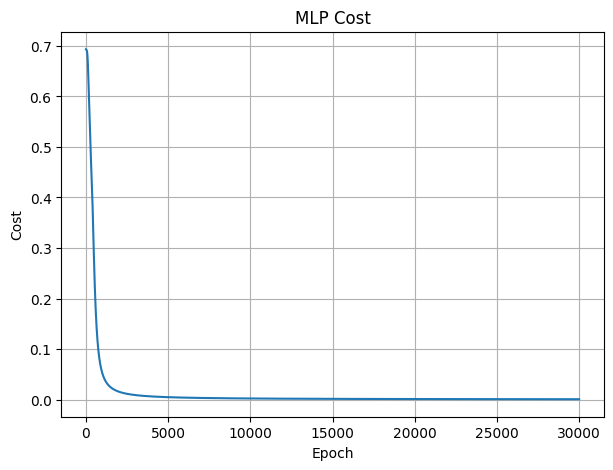

In [18]:
plt.figure(figsize=(7,5))
plt.plot(range(len(cost_history)), cost_history)

plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('MLP Cost')
plt.grid(True)

In [19]:
# 학습결과가 반영된 최종 파라미터로 다시 순전파 실행
# 최종 예측 확률 구하기
H_hidden_1_final, z_hidden_1_final, H_hidden_2_final, z_hidden_2_final, H_output_final, z_output_final = mlp_forward_textbook_style(
    X1_norm, X2_norm, a11, a12, b1, a21, a22, b2, a31, a32, b3
)

In [20]:
pred_mlp = (z_output_final >= 0.5).astype(int)

result_df = pd.DataFrame({
    'temperature': df['temperature'].to_numpy(),
    'humidity': df['humidity'].to_numpy(),
    'y_actual': y.astype(int).ravel(), # 실제 정답
    'z_output_probability': np.round(z_output_final.ravel(), 4), # 최종 예측 확률
    'mlp_pred': pred_mlp.ravel() # 예측 클래스
})

In [21]:
result_df['is_correct'] = result_df['y_actual'] == result_df['mlp_pred']
result_df

,temperature,humidity,y_actual,z_output_probability,mlp_pred,is_correct
0,10,30,0,0.0005,0,True
1,15,40,0,0.0008,0,True
2,20,50,1,0.9994,1,True
3,25,60,1,0.9998,1,True
4,30,70,1,0.9991,1,True
5,35,80,0,0.0009,0,True


In [ ]:
# 순전파 확인용 표
# MLP 내부 계산값 확인
forward_trace_df = pd.DataFrame({
    'temperature': df['temperature'].to_numpy(),
    'humidity': df['humidity'].to_numpy(),
    'y_actual': y.astype(int).ravel(),
    'H_hidden_1': np.round(H_hidden_1_final.ravel(), 4),
    'z_hidden_1': np.round(z_hidden_1_final.ravel(), 4),
    'H_hidden_2': np.round(H_hidden_2_final.ravel(), 4),
    'z_hidden_2': np.round(z_hidden_2_final.ravel(), 4),
    'H_output': np.round(H_output_final.ravel(), 4),
    'z_output': np.round(z_output_final.ravel(), 4)
})
forward_trace_df

,temperature,humidity,y_actual,H_hidden_1,z_hidden_1,H_hidden_2,z_hidden_2,H_output,z_output
0,10,30,0,-23.5019,0.0000,-10.0211,0.0000,-7.6103,0.0005
1,15,40,0,-18.2333,0.0000,-3.5840,0.0270,-7.1811,0.0008
2,20,50,1,-12.9646,0.0000,2.8531,0.9455,7.4362,0.9994
3,25,60,1,-7.6959,0.0005,9.2901,0.9999,8.2951,0.9998
4,30,70,1,-2.4273,0.0811,15.7272,1.0000,6.9900,0.9991
5,35,80,0,2.8414,0.9449,22.1643,1.0000,-7.0012,0.0009


In [ ]:
# 시각화를 위한 온도 습도 격자
# 기존 범위보다 약간 넓게 잡아서 바깥쪽도 보이도록
temp_min = df['temperature'].min() - 2
temp_max = df['temperature'].max() + 2
hum_min = df['humidity'].min() - 2
hum_max = df['humidity'].max() + 2

# 온도와 습도 축을 200개의 점으로 나누고 일정 간격으로 숫자 생성
temp_grid = np.linspace(temp_min, temp_max, 200)
hum_grid = np.linspace(hum_min, hum_max, 200)

# 온도축과 습도축을 조합해서 배경을 칠할 좌표 생성
TEMP, HUM = np.meshgrid(temp_grid, hum_grid)
print('TEMP shape:', TEMP.shape, '| HUM shape:', HUM.shape)

TEMP shape: (200, 200) | HUM shape: (200, 200)


In [ ]:
# 격자 데이터도 정규화
TEMP_norm = (TEMP - X_mean[0, 0]) / X_std[0, 0]
HUM_norm = (HUM -  X_mean[0, 1]) / X_std[0, 1]

In [ ]:
grid_X1 = TEMP_norm.ravel()
grid_X2 = HUM_norm.ravel()

# 학습이 끝난 파라미터로 순전파 실행(결과 확인)
_, _, _, _, _, grid_z_output = mlp_forward_textbook_style(
    grid_X1, grid_X2, a11, a12, b1, a21, a22, b2, a31, a32, b3
)
# z_output 가 0.5 이상이면 1, 아니면 0 으로 예측한 뒤, 다시 격자모양으로
grid_pred = (grid_z_output >= 0.5).astype(int)
grid_pred_2d = grid_pred.reshape(TEMP.shape)

print('grid_pred_2d shape:', grid_pred_2d.shape)

grid_pred_2d shape: (200, 200)


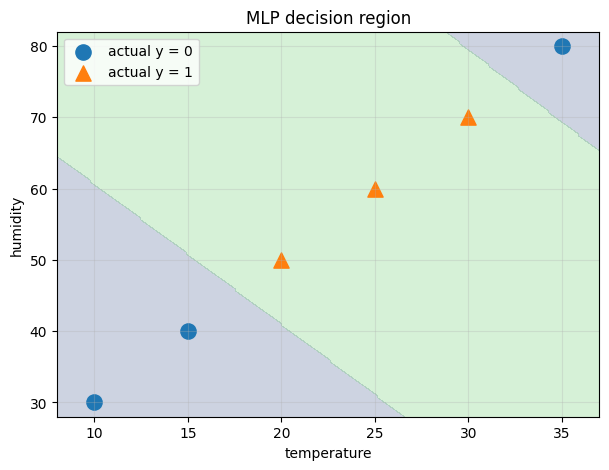

In [34]:
plt.figure(figsize=(7,5))
# 배경: MLP가 0으로 예측한 영역과 1로 예측한 영역
# contourf는 격자위의 예측값 0/1 에 따라 배경 영역을 칠합니다.
# levels는 예측값 0과 1이 서로 다른 영역으로 보이도록 나누는 경계
# alpha=0.25 는 배경색을 연하게 만들어 실제 데이터 점이 가려지지 않게 함

plt.contourf(TEMP, HUM, grid_pred_2d, alpha=0.25, levels=[-0.5, 0.5, 1.5])
mask0 = df['y'] == 0
mask1 = df['y'] == 1

plt.scatter(df.loc[mask0, 'temperature'], df.loc[mask0, 'humidity'], marker='o', s=120, label='actual y = 0')
plt.scatter(df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'], marker='^', s=120, label='actual y = 1')
plt.xlabel('temperature')
plt.ylabel('humidity')
plt.title('MLP decision region')
plt.legend()
plt.grid(True, alpha=0.3)